# 03 - Modèle Decision Tree

## Introduction

Dans ce troisième notebook du projet **Employee Attrition Prediction - RH**, nous entraînons un premier modèle de classification supervisée : le **Decision Tree**.

Le Decision Tree est un modèle simple à comprendre, car il construit des règles de décision successives pour séparer les classes. Il est aussi intéressant dans un premier projet car il permet d'interpréter plus facilement certaines décisions du modèle.

## 1. Importation des bibliothèques

In [260]:
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [261]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

**Interprétation :** Ces bibliothèques permettent de charger les données, de préparer les variables catégorielles, d'entraîner un modèle Decision Tree et d'évaluer ses performances avec plusieurs métriques.

## 2. Chargement du dataset

In [262]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [263]:
df.shape

(1470, 35)

**Interprétation :** Le dataset est rechargé depuis le fichier CSV original. Cette étape permet de repartir des données brutes et d'appliquer le même nettoyage que dans le notebook précédent.

## 3. Nettoyage des colonnes non utiles

In [264]:
columns_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]

# On supprime seulement les colonnes présentes dans le dataset.
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop)

existing_columns_to_drop

['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

**Interprétation :** Ces colonnes sont supprimées car elles sont constantes, identifiantes ou peu utiles pour l'apprentissage. Par exemple, `EmployeeNumber` est un identifiant, tandis que certaines autres colonnes ont la même valeur pour tous les employés.

## 4. Séparation des variables explicatives et de la variable cible

In [265]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("Distribution de la cible :")
print(y.value_counts())

Dimensions de X : (1470, 30)
Dimensions de y : (1470,)
Distribution de la cible :
Attrition
0    1233
1     237
Name: count, dtype: int64


**Interprétation :** `Attrition` est la variable cible à prédire. Elle est transformée en variable numérique : `Yes = 1` signifie que l'employé quitte l'entreprise, et `No = 0` signifie qu'il reste.

## 5. Identification des variables numériques et catégorielles

In [266]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Nombre de variables numériques : {len(numeric_features)}")
print(numeric_features)

print(f"\nNombre de variables catégorielles : {len(categorical_features)}")
print(categorical_features)

Nombre de variables numériques : 23
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Nombre de variables catégorielles : 7
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


**Interprétation :** Les variables numériques peuvent être utilisées directement par le Decision Tree. Les variables catégorielles doivent être transformées en valeurs numériques avant l'entraînement du modèle.

## 6. Création du préprocesseur pour Decision Tree

In [267]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('numeric', 'passthrough',
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'Education', 'EnvironmentSatisfaction',
                                  'HourlyRate', 'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'MonthlyIncome',
                                  'MonthlyRate', 'NumCompaniesWorked',
                                  'PercentSalaryHike', 'PerformanceRating',
                                  'RelationshipSatisfaction',
                                  'StockOptionLevel', 'TotalWorkingYears',
                                  'TrainingTimesLastYear', 'WorkLifeBalance',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                                  'YearsWithCurrManager']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['BusinessTravel', 'Department',
                                  'EducationField', 'Gender', 'JobRole',
                                  'MaritalStatus', 'OverTime'])])

**Interprétation :** Le Decision Tree n'a pas besoin de `StandardScaler`, car il n'est pas sensible à l'échelle des variables comme SVM. Par contre, il a besoin que toutes les variables soient numériques. Les variables catégorielles sont donc encodées avec `OneHotEncoder`.

## 7. Séparation train/test

In [268]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (1176, 30)
X_test : (294, 30)
y_train : (1176,)
y_test : (294,)


In [269]:
print("Distribution de y_train :")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribution de y_test :")
print(y_test.value_counts(normalize=True) * 100)

Distribution de y_train :
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64

Distribution de y_test :
Attrition
0    84.013605
1    15.986395
Name: proportion, dtype: float64


**Interprétation :** `random_state=42` rend les résultats reproductibles. L'argument `stratify=y` permet de garder une proportion similaire des classes **Attrition Yes/No** dans les ensembles d'entraînement et de test, ce qui est important car la classe des départs est minoritaire.

## 8. Création du pipeline Decision Tree

In [270]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42)),
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOp...
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

**Interprétation :** Le pipeline regroupe le prétraitement et le modèle dans un seul objet. Cela permet d'appliquer automatiquement les mêmes transformations aux données d'entraînement et aux données de test.

## 9. Entraînement du modèle

In [271]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOp...
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

**Interprétation :** Le modèle apprend à partir des données d'entraînement. Il cherche des règles de décision qui permettent de distinguer les employés qui restent de ceux qui quittent l'entreprise.

## 10. Prédictions sur les données de test

In [272]:
y_pred = model.predict(X_test)
y_pred[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

**Interprétation :** Les prédictions sont faites sur les données de test, qui n'ont pas été utilisées pendant l'entraînement. Cela permet d'évaluer la capacité du modèle à généraliser sur de nouvelles données.

## 11. Évaluation du modèle

In [273]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame(
    {
        "model": ["Decision Tree"],
        "accuracy": [accuracy],
        "precision": [precision],
        "recall": [recall],
        "f1_score": [f1],
    }
)

metrics_df

,model,accuracy,precision,recall,f1_score
0,Decision Tree,0.765306,0.310345,0.382979,0.342857


**Interprétation des métriques :**

- **Accuracy** : proportion globale des bonnes prédictions parmi tous les employés du test.
- **Precision** : parmi les employés prédits comme départ, elle indique combien sont réellement des départs.
- **Recall** : parmi les vrais départs, elle indique combien le modèle a réussi à détecter.
- **F1-score** : équilibre entre la precision et le recall.

On remarque que le modèle Decision Tree obtient une accuracy de 0,7653, soit environ 76,53 %.

Cela signifie que le modèle prédit correctement une partie importante des employés.
Mais dans un projet d’attrition, il ne faut pas se baser uniquement sur l’accuracy, car les classes peuvent être déséquilibrées.
Il y a souvent beaucoup plus d’employés qui restent que d’employés qui quittent l’entreprise.

La précision est de 0,3103, soit environ 31,03 %.
Cela signifie que, parmi les employés prédits comme risquant de quitter l’entreprise, seulement une partie est réellement en attrition.
Le modèle fait donc encore plusieurs fausses alertes.

Le recall est de 0,3830, soit environ 38,30 %.
Cela signifie que le modèle arrive à détecter seulement une partie des employés qui ont réellement quitté l’entreprise.
Il manque donc encore beaucoup d’employés à risque.

Le F1-score est de 0,3429, soit environ 34,29 %.
Ce score montre que l’équilibre entre la précision et le recall reste faible.
Cela signifie que le modèle Decision Tree n’est pas encore très performant pour détecter correctement les employés qui risquent de quitter l’entreprise.

Cette observation est importante car l’objectif principal du projet n’est pas seulement de prédire les employés qui restent, mais surtout d’identifier les employés avec Attrition = Yes.

In [274]:
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.88      0.84      0.86       247
         Yes       0.31      0.38      0.34        47

    accuracy                           0.77       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.77      0.77       294



**Interprétation :** On remarque que le modèle Decision Tree baseline obtient une accuracy globale de 0,77, soit environ 77 %.

Le modèle prédit bien la classe No, c’est-à-dire les employés qui ne quittent pas l’entreprise.
Pour cette classe, la précision est de 0,88, le recall est de 0,84 et le F1-score est de 0,86.
Cela montre que le modèle reconnaît assez bien les employés qui restent.

Par contre, pour la classe Yes, les résultats sont faibles.
La précision est de 0,31, le recall est de 0,38 et le F1-score est de 0,34.
Cela signifie que le modèle détecte difficilement les employés qui quittent réellement l’entreprise.

On remarque aussi que la classe No contient 247 employés, alors que la classe Yes contient seulement 47 employés.
Cela montre que les classes sont déséquilibrées.
Pour cette raison, l’accuracy seule ne suffit pas pour juger la performance du modèle.

## 12. Matrice de confusion

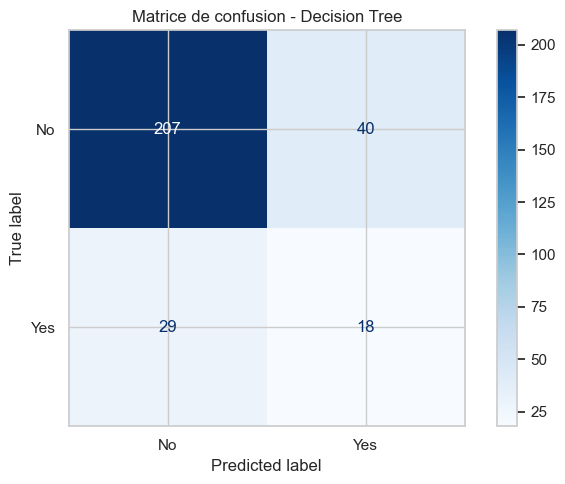

In [275]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"],
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Matrice de confusion - Decision Tree")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** La matrice de confusion permet de voir les bonnes et mauvaises prédictions du modèle.

- Les **vrais négatifs** sont les employés qui restent et que le modèle prédit correctement comme `No`.
- Les **faux positifs** sont les employés prédits comme départ alors qu'ils restent réellement.
- Les **faux négatifs** sont les employés qui quittent réellement l'entreprise mais que le modèle n'a pas détectés.
- Les **vrais positifs** sont les employés qui quittent et que le modèle prédit correctement comme `Yes`.

On remarque que la matrice de confusion du Decision Tree baseline contient 4 valeurs principales.

Le modèle a correctement prédit 207 employés comme Attrition = No.
Cela signifie que ces employés ne quittent pas l’entreprise, et le modèle a bien prédit cette classe.

Le modèle a aussi correctement prédit 18 employés comme Attrition = Yes.
Cela signifie que ces employés ont réellement quitté l’entreprise, et le modèle a réussi à les détecter.

Par contre, le modèle a prédit 40 employés comme Attrition = Yes, alors qu’ils sont réellement No.
Ce sont des fausses alertes.
Cela veut dire que le modèle pense que certains employés vont quitter l’entreprise, alors qu’ils restent.

Le modèle a aussi prédit 29 employés comme Attrition = No, alors qu’ils sont réellement Yes.
C’est le cas le plus important dans notre projet, car cela signifie que le modèle a raté 29 employés qui ont réellement quitté l’entreprise.

Même si le modèle prédit bien beaucoup d’employés qui restent, il a encore des difficultés à reconnaître les employés qui risquent de quitter l’entreprise.

On remarque aussi que la classe No est beaucoup plus présente que la classe Yes.
Donc, il ne faut pas se baser uniquement sur l’accuracy, car le modèle peut paraître correct surtout grâce à la bonne prédiction de la classe majoritaire.

## 13. Visualisation simple de l'arbre

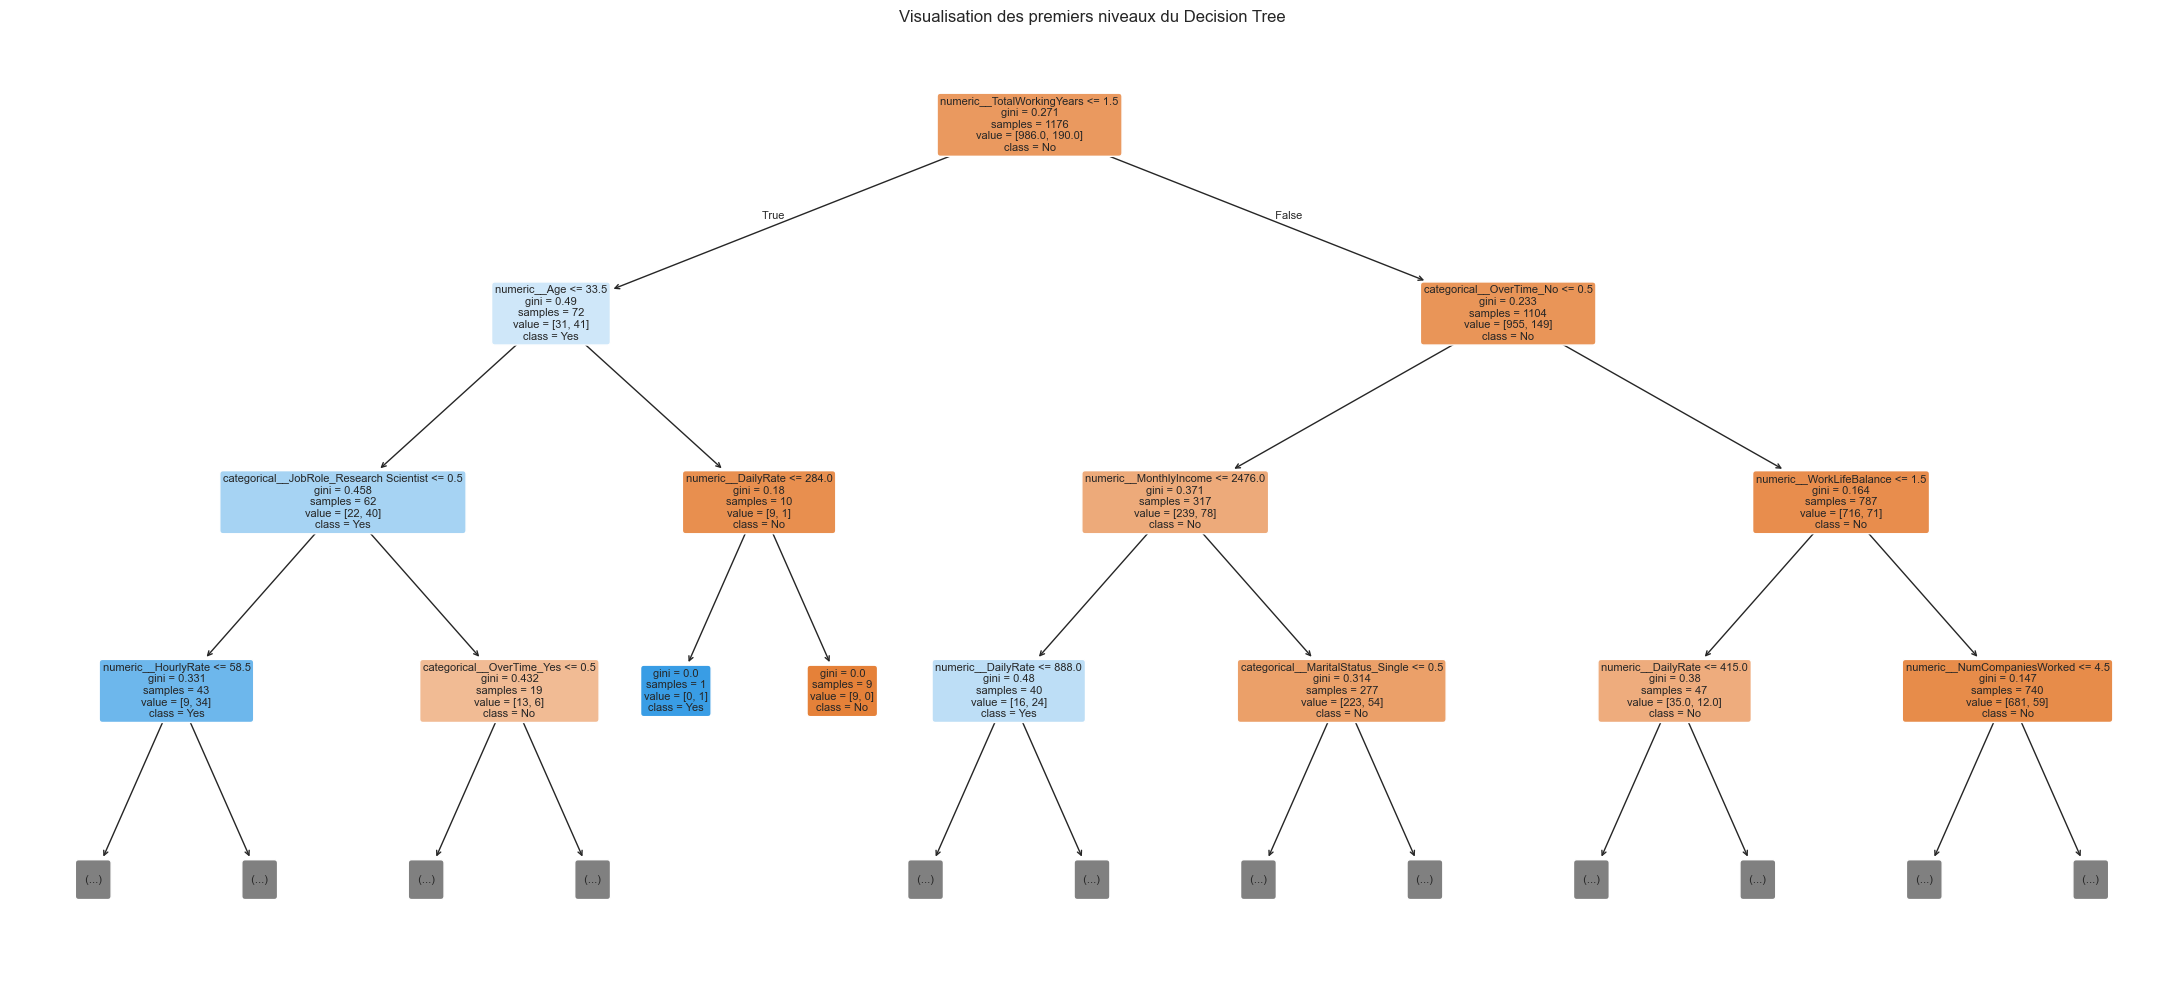

In [276]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
tree_classifier = model.named_steps["classifier"]

plt.figure(figsize=(22, 10))
plot_tree(
    tree_classifier,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Visualisation des premiers niveaux du Decision Tree")
plt.tight_layout()
plt.savefig("../results/figures/decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que cette visualisation représente les premiers niveaux du Decision Tree baseline.

La première variable utilisée par l’arbre est TotalWorkingYears.
Le premier test est :

TotalWorkingYears <= 1.5

Cela signifie que le modèle considère que le nombre total d’années d’expérience est une variable importante pour séparer les employés qui quittent et ceux qui restent.

Dans le nœud principal, on observe :

samples = 1176
value = [986, 190]
class = No

Cela signifie que, dans les données d’entraînement, la majorité des employés appartiennent à la classe Attrition = No.
On remarque donc encore le déséquilibre entre les classes.

Pour les employés avec peu d’expérience (TotalWorkingYears <= 1.5), l’arbre continue avec la variable Age.
Dans cette branche, la classe prédite est souvent Yes.
Cela montre que les employés avec très peu d’expérience peuvent être plus liés au risque d’attrition.

Pour les employés avec plus d’expérience (TotalWorkingYears > 1.5), l’arbre utilise ensuite la variable OverTime.
Cela montre que les heures supplémentaires jouent aussi un rôle important dans la décision du modèle.

On remarque aussi que l’arbre utilise d’autres variables dans les niveaux suivants, comme MonthlyIncome, WorkLifeBalance, DailyRate, JobRole, MaritalStatus et NumCompaniesWorked.
Cela signifie que le modèle ne se base pas sur une seule variable, mais combine plusieurs informations RH pour faire sa prédiction.

Les nœuds orange représentent surtout la classe No, c’est-à-dire les employés qui restent dans l’entreprise.
Les nœuds bleus représentent surtout la classe Yes, c’est-à-dire les employés qui quittent l’entreprise.

Cette visualisation est importante car elle permet de comprendre comment le Decision Tree prend ses décisions.
Contrairement à certains modèles plus complexes, l’arbre de décision est assez interprétable : on peut voir les variables utilisées et l’ordre des conditions.

## 14. Sauvegarde des métriques

In [277]:
metrics_dir = "../results/metrics"
os.makedirs(metrics_dir, exist_ok=True)

metrics_df.to_csv(f"{metrics_dir}/decision_tree_metrics.csv", index=False)
print("Métriques sauvegardées dans ../results/metrics/decision_tree_metrics.csv")

Métriques sauvegardées dans ../results/metrics/decision_tree_metrics.csv


**Interprétation :** Les métriques sont sauvegardées dans un fichier CSV. Cela permettra de comparer plus facilement ce modèle avec les prochains modèles du projet.

## 15. Sauvegarde du modèle

In [278]:
models_dir = "../results/models"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(model, f"{models_dir}/decision_tree_model.joblib")
print("Modèle sauvegardé dans ../results/models/decision_tree_model.joblib")

Modèle sauvegardé dans ../results/models/decision_tree_model.joblib


**Interprétation :** Le pipeline complet est sauvegardé avec `joblib`. Il contient à la fois le prétraitement et le modèle Decision Tree, ce qui permet de réutiliser le modèle plus facilement plus tard.

## 16. Amélioration du modèle Decision Tree

Le premier Decision Tree donne une accuracy correcte, mais la précision, le recall et le F1-score pour la classe **Attrition = Yes** restent faibles. Cela montre que le modèle détecte difficilement les employés qui risquent réellement de quitter l’entreprise.

Cette limite peut être liée au déséquilibre des classes : les employés qui quittent l’entreprise sont moins nombreux que ceux qui restent. Pour cette raison, nous testons une version améliorée du Decision Tree en utilisant un rééquilibrage des classes et en limitant la complexité de l’arbre.

### 16.1 Création du modèle Decision Tree amélioré

In [279]:
dt_model_improved = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced",
            max_depth=5,
            min_samples_leaf=10,
        )),
    ]
)

dt_model_improved

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOp...
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

**Interprétation :** Ce modèle garde le même préprocesseur que le modèle baseline. La différence vient du Decision Tree : `class_weight="balanced"` donne plus d’importance à la classe minoritaire, `max_depth=5` limite la profondeur de l’arbre, et `min_samples_leaf=10` impose un nombre minimum d’observations dans chaque feuille.

### 16.2 Entraînement du modèle amélioré

In [280]:
dt_model_improved.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOp...
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

**Interprétation :** Le modèle amélioré apprend à partir des mêmes données d’entraînement que le modèle baseline. Cela permet de comparer les deux modèles dans les mêmes conditions.

### 16.3 Prédictions du modèle amélioré

In [281]:
y_pred_dt_improved = dt_model_improved.predict(X_test)
y_pred_dt_improved[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

**Interprétation :** Les prédictions sont réalisées sur les données de test. Ces données n’ont pas été utilisées pendant l’entraînement, ce qui permet d’évaluer le modèle sur de nouvelles observations.

### 16.4 Évaluation du modèle amélioré

In [282]:
accuracy_dt_improved = accuracy_score(y_test, y_pred_dt_improved)
precision_dt_improved = precision_score(y_test, y_pred_dt_improved, zero_division=0)
recall_dt_improved = recall_score(y_test, y_pred_dt_improved, zero_division=0)
f1_dt_improved = f1_score(y_test, y_pred_dt_improved, zero_division=0)

metrics_dt_improved_df = pd.DataFrame(
    {
        "model": ["Decision Tree Improved"],
        "accuracy": [accuracy_dt_improved],
        "precision": [precision_dt_improved],
        "recall": [recall_dt_improved],
        "f1_score": [f1_dt_improved],
    }
)

metrics_dt_improved_df

,model,accuracy,precision,recall,f1_score
0,Decision Tree Improved,0.768707,0.356164,0.553191,0.433333


**Interprétation :** On remarque que le modèle Decision Tree Improved obtient une accuracy de 0,7687, soit environ 76,87 %.

Cette accuracy est presque la même que celle du premier Decision Tree.
Cela signifie que l’amélioration du modèle n’a pas beaucoup changé le pourcentage global de bonnes prédictions.

Par contre, la précision est passée à 0,3562, soit environ 35,62 %.
Cela signifie que, parmi les employés prédits comme Attrition = Yes, le modèle se trompe encore, mais il fait un peu mieux que le premier Decision Tree.

Le recall est de 0,5532, soit environ 55,32 %.
C’est une amélioration importante par rapport au premier modèle.
Cela signifie que le modèle arrive maintenant à détecter plus de la moitié des employés qui ont réellement quitté l’entreprise.

Le F1-score est de 0,4333, soit environ 43,33 %.
Ce score est meilleur que celui du modèle baseline.
Cela montre que l’équilibre entre la précision et le recall s’est amélioré. 

Cependant, la précision reste encore faible.

Cela veut dire que le modèle peut encore prédire certains employés comme risquant de quitter l’entreprise alors qu’ils restent finalement.

In [283]:
print(classification_report(y_test, y_pred_dt_improved, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.90      0.81      0.85       247
         Yes       0.36      0.55      0.43        47

    accuracy                           0.77       294
   macro avg       0.63      0.68      0.64       294
weighted avg       0.82      0.77      0.79       294



**Interprétation :** On remarque que le modèle Decision Tree Improved obtient une accuracy globale de 0,77, soit environ 77 %.

Cette accuracy est presque la même que celle du Decision Tree baseline.
Cela signifie que l’amélioration n’a pas beaucoup changé le nombre total de bonnes prédictions.

Pour la classe No, la précision est de 0,90.
Cela signifie que lorsque le modèle prédit qu’un employé ne quitte pas l’entreprise, il a souvent raison.

Le recall de la classe No est de 0,81.
Cela signifie que le modèle retrouve une grande partie des employés qui restent réellement dans l’entreprise.

Le F1-score de la classe No est de 0,85.
Cela montre que le modèle reste performant pour reconnaître les employés qui ne quittent pas l’entreprise.

Pour la classe Yes, la précision est de 0,36.
Cela signifie que parmi les employés prédits comme risquant de quitter l’entreprise, une partie seulement quitte réellement l’entreprise.

Le recall de la classe Yes est de 0,55.
Cela signifie que le modèle arrive maintenant à détecter plus de la moitié des employés qui ont réellement quitté l’entreprise.

Le F1-score de la classe Yes est de 0,43.
Ce score reste moyen, mais il est meilleur que celui du Decision Tree baseline.
Cela montre que le modèle amélioré détecte mieux la classe importante Attrition = Yes.

### 16.5 Matrice de confusion du modèle amélioré

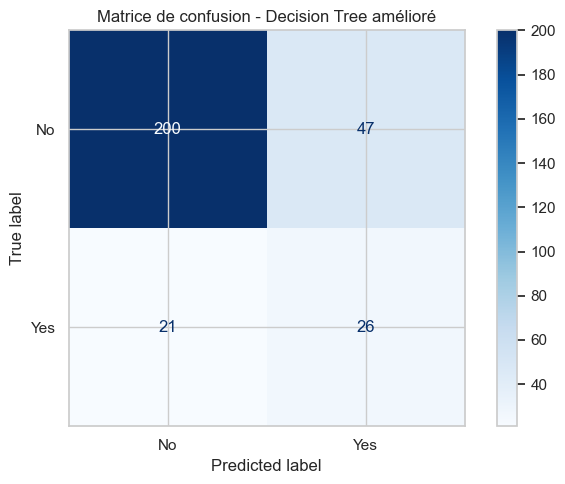

In [284]:
cm_dt_improved = confusion_matrix(y_test, y_pred_dt_improved)

disp_dt_improved = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_improved,
    display_labels=["No", "Yes"],
)

fig, ax = plt.subplots(figsize=(7, 5))
disp_dt_improved.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Matrice de confusion - Decision Tree amélioré")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_decision_tree_improved.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que la matrice de confusion du Decision Tree Improved montre les bonnes et les mauvaises prédictions du modèle.

Le modèle a correctement prédit 200 employés comme Attrition = No.
Cela signifie que ces employés ne quittent pas l’entreprise, et le modèle les a bien classés.

Le modèle a aussi correctement prédit 26 employés comme Attrition = Yes.
Cela signifie que le modèle a réussi à détecter 26 employés qui ont réellement quitté l’entreprise.

Par contre, le modèle a prédit 47 employés comme Attrition = Yes, alors qu’ils sont réellement No.
Ce sont des fausses alertes.
Cela veut dire que le modèle pense que certains employés vont quitter l’entreprise, alors qu’ils restent.

Le modèle a aussi prédit 21 employés comme Attrition = No, alors qu’ils sont réellement Yes.
Cela signifie que le modèle a raté 21 employés qui ont réellement quitté l’entreprise.

Par rapport au Decision Tree baseline, le modèle amélioré détecte mieux les employés qui quittent l’entreprise, car il trouve 26 cas Yes au lieu de 18 auparavant.

Cependant, le nombre de fausses alertes augmente aussi.
Cela montre que le modèle devient plus sensible à la classe Yes, mais il se trompe davantage sur certains employés qui restent.

### 16.6 Sauvegarde des métriques et du modèle amélioré

In [285]:
metrics_dt_improved_df.to_csv(
    "../results/metrics/decision_tree_improved_metrics.csv",
    index=False,
)

joblib.dump(
    dt_model_improved,
    "../results/models/decision_tree_improved_model.joblib",
)

print("Métriques sauvegardées dans ../results/metrics/decision_tree_improved_metrics.csv")
print("Modèle sauvegardé dans ../results/models/decision_tree_improved_model.joblib")

Métriques sauvegardées dans ../results/metrics/decision_tree_improved_metrics.csv
Modèle sauvegardé dans ../results/models/decision_tree_improved_model.joblib


**Interprétation :** Les métriques et le pipeline complet du modèle amélioré sont sauvegardés. Cela permet de conserver cette expérimentation et de la comparer avec les autres modèles du projet.

## 17. Comparaison entre le modèle baseline et le modèle amélioré

In [286]:
baseline_metrics_df = metrics_df.copy()
baseline_metrics_df["model"] = "Decision Tree Baseline"

comparison_dt_df = pd.concat(
    [baseline_metrics_df, metrics_dt_improved_df],
    ignore_index=True,
)

comparison_dt_df[["model", "accuracy", "precision", "recall", "f1_score"]]

,model,accuracy,precision,recall,f1_score
0,Decision Tree Baseline,0.765306,0.310345,0.382979,0.342857
1,Decision Tree Improved,0.768707,0.356164,0.553191,0.433333


Ce tableau permet de comparer directement le Decision Tree baseline et le Decision Tree amélioré. On peut observer si l’amélioration augmente le recall, la précision ou le F1-score, et si elle change beaucoup l’accuracy.

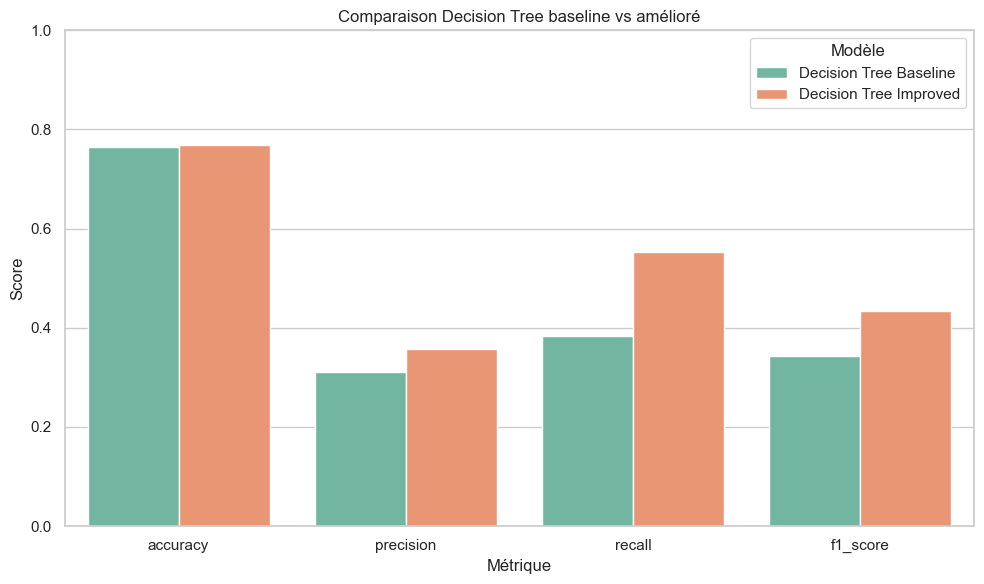

In [287]:
comparison_dt_long = comparison_dt_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_dt_long,
    x="metric",
    y="score",
    hue="model",
)
plt.title("Comparaison Decision Tree baseline vs amélioré")
plt.xlabel("Métrique")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Modèle")
plt.tight_layout()
plt.savefig("../results/figures/decision_tree_baseline_vs_improved.png", dpi=300, bbox_inches="tight")
plt.show()

Ce graphique permet de visualiser plus facilement les différences entre les deux versions du Decision Tree. Il aide à voir le compromis éventuel entre accuracy, precision, recall et F1-score.

**Interprétation de la comparaison :** On remarque que les deux modèles ont presque la même accuracy.
Le Decision Tree Baseline obtient une accuracy de 0,7653, tandis que le Decision Tree Improved obtient 0,7687.

Cela signifie que l’amélioration du modèle n’a pas beaucoup changé la performance globale.
Les deux modèles prédisent correctement environ 76 % à 77 % des cas.

Cependant, l’accuracy seule ne suffit pas pour juger le modèle, car le dataset est déséquilibré.
Dans ce projet, l’objectif principal est surtout de bien détecter les employés avec Attrition = Yes.

On remarque que la precision augmente légèrement.
Elle passe de 0,3103 pour le modèle baseline à 0,3562 pour le modèle amélioré.
Cela signifie que le modèle amélioré fait un peu moins d’erreurs lorsqu’il prédit qu’un employé risque de quitter l’entreprise.

Le changement le plus important concerne le recall.
Il passe de 0,3830 à 0,5532.
Cela signifie que le modèle amélioré détecte beaucoup plus d’employés qui ont réellement quitté l’entreprise.

Le F1-score augmente aussi, de 0,3429 à 0,4333.
Cela montre que l’équilibre entre la precision et le recall est meilleur avec le modèle amélioré.

## Conclusion partielle de l’amélioration

Le modèle **Decision Tree baseline** sert de point de départ. Le modèle **Decision Tree amélioré** permet de tester l’effet du rééquilibrage des classes et du contrôle de la complexité de l’arbre.

Cette comparaison permet de mieux comprendre les limites du Decision Tree avant de passer au modèle **Random Forest**, qui sera un modèle plus robuste basé sur plusieurs arbres.

## Conclusion générale du notebook

Dans ce notebook, un modèle **Decision Tree baseline** puis un modèle **Decision Tree amélioré** ont été entraînés pour prédire l'attrition des employés.

Ce modèle est simple et interprétable, car il repose sur des règles de décision. Les métriques comme l'accuracy, la precision, le recall et le F1-score permettent d'évaluer ses performances de manière plus complète.

La matrice de confusion montre les bonnes et les mauvaises prédictions, notamment les faux négatifs, qui sont importants dans ce projet car ils correspondent à des employés à risque non détectés.

Les modèles et leurs métriques ont été sauvegardés pour permettre une comparaison avec les prochains modèles.

La prochaine étape sera l'entraînement du modèle **Random Forest**, afin de comparer ce premier arbre avec un modèle plus robuste basé sur plusieurs arbres.